# Convolutional Neural Network (CNN) on Image Datasets
## MNIST and CIFAR-10 Classification

This notebook demonstrates:
- Building CNN architectures
- Image data preprocessing
- Training on MNIST and CIFAR-10
- Transfer learning concepts

### 1. Import Libraries and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.21.0


GPU Available: []


### 2. Load and Prepare MNIST Dataset

In [2]:
# Load MNIST dataset
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

# Normalize images
X_train_mnist = X_train_mnist.astype('float32') / 255.0
X_test_mnist = X_test_mnist.astype('float32') / 255.0

# Reshape for CNN (add channel dimension)
X_train_mnist = X_train_mnist.reshape(-1, 28, 28, 1)
X_test_mnist = X_test_mnist.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train_mnist_enc = keras.utils.to_categorical(y_train_mnist, 10)
y_test_mnist_enc = keras.utils.to_categorical(y_test_mnist, 10)

print(f"MNIST Dataset:")
print(f"Training Shape: {X_train_mnist.shape}")
print(f"Test Shape: {X_test_mnist.shape}")
print(f"Training Labels Shape: {y_train_mnist_enc.shape}")

       0/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:02 5us/step

   32768/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:00 5us/step

   49152/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:36 8us/step

   81920/11490434 ━━━━━━━━━━━━━━━━━━━━ 1:40 9us/step

...

10240000/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

10780672/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11403264/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


MNIST Dataset:
Training Shape: (60000, 28, 28, 1)
Test Shape: (10000, 28, 28, 1)
Training Labels Shape: (60000, 10)


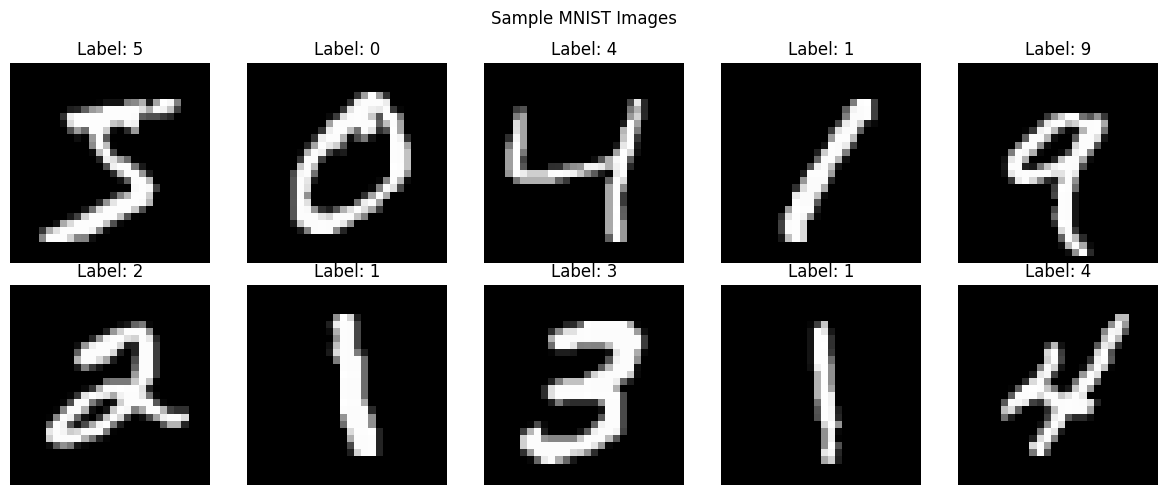

In [3]:
# Visualize MNIST samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_mnist[i].reshape(28, 28), cmap='gray')
    ax.set_title(f'Label: {y_train_mnist[i]}')
    ax.axis('off')
plt.suptitle('Sample MNIST Images')
plt.tight_layout()
plt.show()

### 3. Build Simple CNN for MNIST

In [4]:
# Build simple CNN
def create_simple_cnn():
    model = models.Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D((2, 2)),
        
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(10, activation='softmax')
    ])
    return model

simple_cnn = create_simple_cnn()
simple_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
simple_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Train simple CNN
print("Training Simple CNN on MNIST...")
history_simple = simple_cnn.fit(
    X_train_mnist, y_train_mnist_enc,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

# Evaluate
train_loss_s, train_acc_s = simple_cnn.evaluate(X_train_mnist, y_train_mnist_enc, verbose=0)
test_loss_s, test_acc_s = simple_cnn.evaluate(X_test_mnist, y_test_mnist_enc, verbose=0)

print(f"\nSimple CNN Results:")
print(f"Training Accuracy: {train_acc_s:.4f}")
print(f"Testing Accuracy: {test_acc_s:.4f}")

Training Simple CNN on MNIST...
Epoch 1/10


  1/422 ━━━━━━━━━━━━━━━━━━━━ 12:55 2s/step - accuracy: 0.1328 - loss: 2.2959

  4/422 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.1504 - loss: 2.2741 

  7/422 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.1785 - loss: 2.2490

 10/422 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.2049 - loss: 2.2210

...

412/422 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9921 - loss: 0.0238

416/422 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9921 - loss: 0.0238

420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9921 - loss: 0.0238

422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9922 - loss: 0.0250 - val_accuracy: 0.9915 - val_loss: 0.0316



Simple CNN Results:
Training Accuracy: 0.9963
Testing Accuracy: 0.9908


### 4. Build Advanced CNN for MNIST

In [6]:
# Build advanced CNN
def create_advanced_cnn():
    model = models.Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        Dense(10, activation='softmax')
    ])
    return model

advanced_cnn = create_advanced_cnn()
advanced_cnn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
advanced_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,882 (1.39 MB)

 Trainable params: 362,730 (1.38 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [7]:
# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2
)

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

# Train advanced CNN with augmentation
print("Training Advanced CNN on MNIST with Data Augmentation...")
history_advanced = advanced_cnn.fit(
    datagen.flow(X_train_mnist, y_train_mnist_enc, batch_size=128),
    epochs=20,
    steps_per_epoch=len(X_train_mnist) // 128,
    validation_data=(X_test_mnist, y_test_mnist_enc),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate
train_loss_a, train_acc_a = advanced_cnn.evaluate(X_train_mnist, y_train_mnist_enc, verbose=0)
test_loss_a, test_acc_a = advanced_cnn.evaluate(X_test_mnist, y_test_mnist_enc, verbose=0)

print(f"\nAdvanced CNN Results:")
print(f"Training Accuracy: {train_acc_a:.4f}")
print(f"Testing Accuracy: {test_acc_a:.4f}")

Training Advanced CNN on MNIST with Data Augmentation...


Epoch 1/20


  1/468 ━━━━━━━━━━━━━━━━━━━━ 36:17 5s/step - accuracy: 0.0938 - loss: 3.5837

  2/468 ━━━━━━━━━━━━━━━━━━━━ 38s 83ms/step - accuracy: 0.1055 - loss: 3.5481

  3/468 ━━━━━━━━━━━━━━━━━━━━ 35s 76ms/step - accuracy: 0.1137 - loss: 3.5022

...

468/468 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.9767 - loss: 0.0803 - val_accuracy: 0.9941 - val_loss: 0.0195 - learning_rate: 5.0000e-04


Epoch 10/20


  1/468 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.9766 - loss: 0.0641

468/468 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9766 - loss: 0.0641 - val_accuracy: 0.9940 - val_loss: 0.0197 - learning_rate: 5.0000e-04



Advanced CNN Results:
Training Accuracy: 0.9911
Testing Accuracy: 0.9943


### 5. Visualize MNIST Results

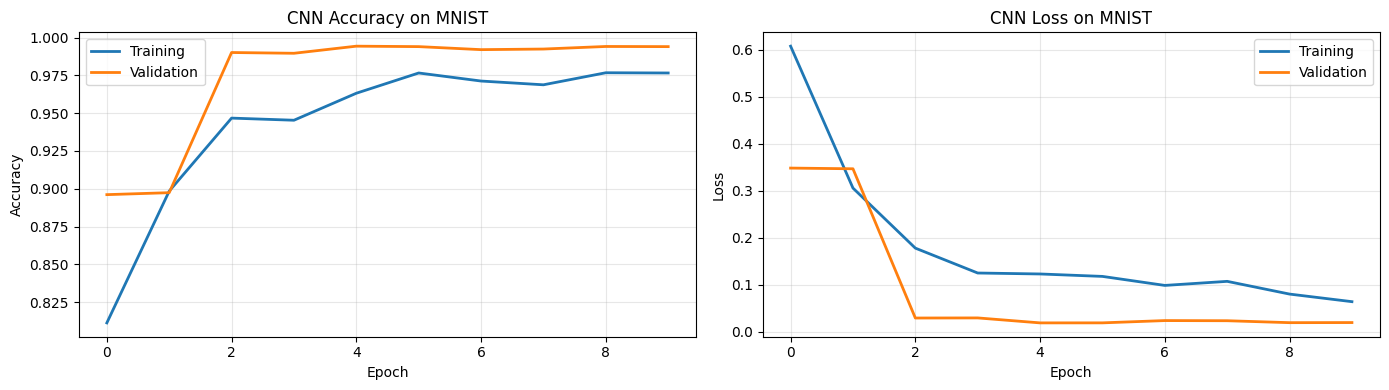

In [8]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
axes[0].plot(history_advanced.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history_advanced.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('CNN Accuracy on MNIST')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_advanced.history['loss'], label='Training', linewidth=2)
axes[1].plot(history_advanced.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('CNN Loss on MNIST')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

  1/313 ━━━━━━━━━━━━━━━━━━━━ 56s 181ms/step

  8/313 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step   

 15/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

 22/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

 29/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

...

291/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

298/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

306/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


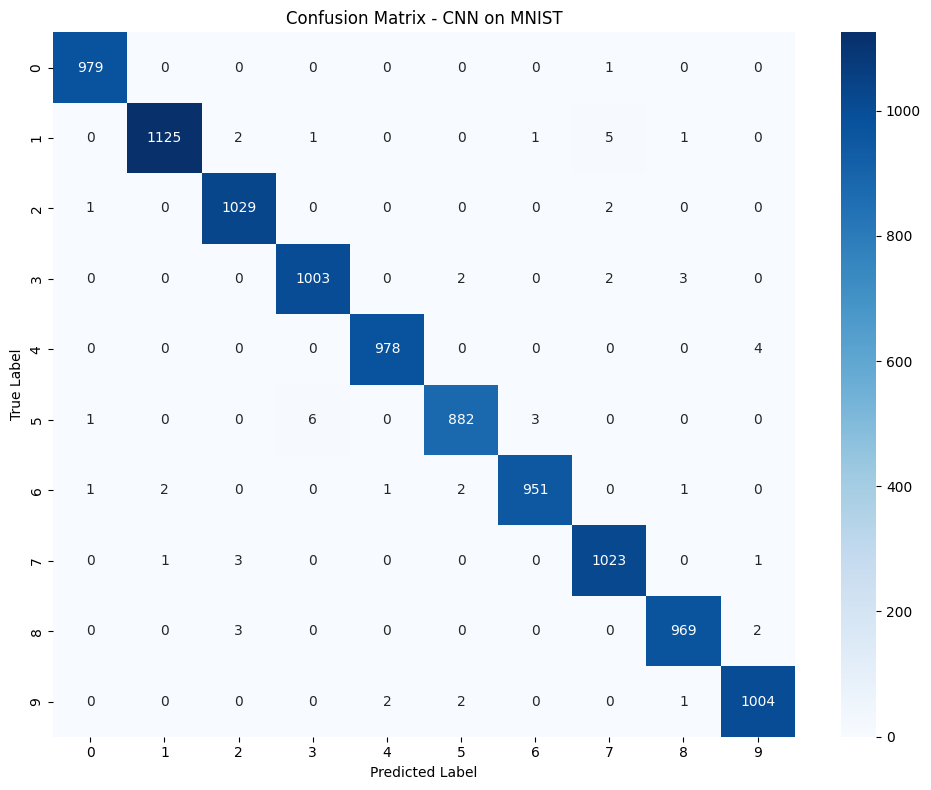

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      1.00      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [9]:
# Confusion matrix
y_pred = advanced_cnn.predict(X_test_mnist)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_mnist, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CNN on MNIST')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Classification report
print("Classification Report:")
print(classification_report(y_test_mnist, y_pred_classes))

### 6. Load and Prepare CIFAR-10 Dataset

In [10]:
# Load CIFAR-10 dataset
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

# Normalize images
X_train_cifar = X_train_cifar.astype('float32') / 255.0
X_test_cifar = X_test_cifar.astype('float32') / 255.0

# Flatten labels
y_train_cifar = y_train_cifar.flatten()
y_test_cifar = y_test_cifar.flatten()

# One-hot encode
y_train_cifar_enc = keras.utils.to_categorical(y_train_cifar, 10)
y_test_cifar_enc = keras.utils.to_categorical(y_test_cifar, 10)

print(f"CIFAR-10 Dataset:")
print(f"Training Shape: {X_train_cifar.shape}")
print(f"Test Shape: {X_test_cifar.shape}")

# Class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

        0/170498071 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

     8192/170498071 ━━━━━━━━━━━━━━━━━━━━ 1:27:12 31us/step

    40960/170498071 ━━━━━━━━━━━━━━━━━━━━ 39:25 14us/step  

    98304/170498071 ━━━━━━━━━━━━━━━━━━━━ 23:53 8us/step 

   212992/170498071 ━━━━━━━━━━━━━━━━━━━━ 15:08 5us/step

...

169730048/170498071 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

170033152/170498071 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

170409984/170498071 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 188s 1us/step


CIFAR-10 Dataset:
Training Shape: (50000, 32, 32, 3)
Test Shape: (10000, 32, 32, 3)


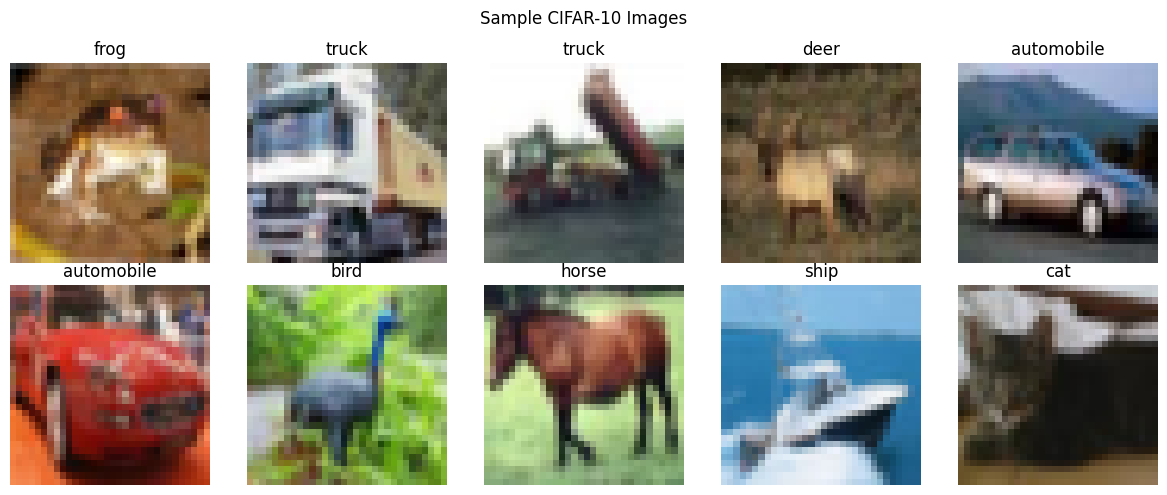

In [11]:
# Visualize CIFAR-10 samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train_cifar[i])
    ax.set_title(f'{class_names[y_train_cifar[i]]}')
    ax.axis('off')
plt.suptitle('Sample CIFAR-10 Images')
plt.tight_layout()
plt.show()

### 7. Build Deep CNN for CIFAR-10

In [12]:
# Build deep CNN for CIFAR-10
def create_deep_cnn_cifar():
    model = models.Sequential([
        Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        Dense(10, activation='softmax')
    ])
    return model

deep_cnn_cifar = create_deep_cnn_cifar()
deep_cnn_cifar.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deep_cnn_cifar.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 849,066 (3.24 MB)

 Trainable params: 847,402 (3.23 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [13]:
# Data augmentation for CIFAR-10
datagen_cifar = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Train deep CNN on CIFAR-10
print("Training Deep CNN on CIFAR-10 with Data Augmentation...")
history_cifar = deep_cnn_cifar.fit(
    datagen_cifar.flow(X_train_cifar, y_train_cifar_enc, batch_size=64),
    epochs=50,
    steps_per_epoch=len(X_train_cifar) // 64,
    validation_data=(X_test_cifar, y_test_cifar_enc),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate
train_loss_c, train_acc_c = deep_cnn_cifar.evaluate(X_train_cifar, y_train_cifar_enc, verbose=0)
test_loss_c, test_acc_c = deep_cnn_cifar.evaluate(X_test_cifar, y_test_cifar_enc, verbose=0)

print(f"\nDeep CNN (CIFAR-10) Results:")
print(f"Training Accuracy: {train_acc_c:.4f}")
print(f"Testing Accuracy: {test_acc_c:.4f}")

Training Deep CNN on CIFAR-10 with Data Augmentation...
Epoch 1/50


  1/781 ━━━━━━━━━━━━━━━━━━━━ 1:40:39 8s/step - accuracy: 0.1094 - loss: 3.5375

  2/781 ━━━━━━━━━━━━━━━━━━━━ 1:17 100ms/step - accuracy: 0.1211 - loss: 3.4084

  3/781 ━━━━━━━━━━━━━━━━━━━━ 1:27 112ms/step - accuracy: 0.1345 - loss: 3.3185

  4/781 ━━━━━━━━━━━━━━━━━━━━ 1:31 117ms/step - accuracy: 0.1380 - loss: 3.3061

...

779/781 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5181 - loss: 1.3481

780/781 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5181 - loss: 1.3481

781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5181 - loss: 1.3481

781/781 ━━━━━━━━━━━━━━━━━━━━ 123s 157ms/step - accuracy: 0.5286 - loss: 1.3231 - val_accuracy: 0.5896 - val_loss: 1.1340 - learning_rate: 5.0000e-04



Deep CNN (CIFAR-10) Results:
Training Accuracy: 0.3699
Testing Accuracy: 0.3675


### 8. Visualize CIFAR-10 Results

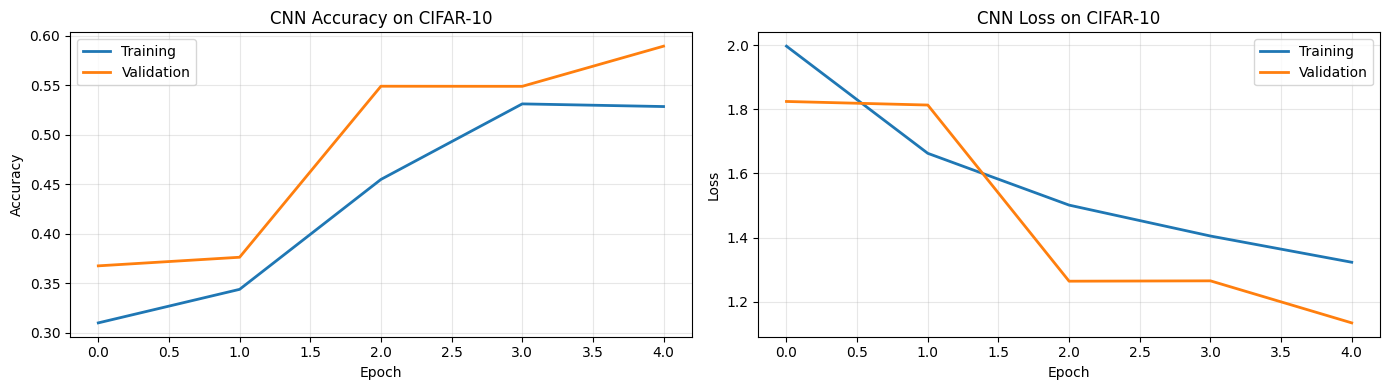

In [14]:
# Plot CIFAR-10 training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy
axes[0].plot(history_cifar.history['accuracy'], label='Training', linewidth=2)
axes[0].plot(history_cifar.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('CNN Accuracy on CIFAR-10')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_cifar.history['loss'], label='Training', linewidth=2)
axes[1].plot(history_cifar.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('CNN Loss on CIFAR-10')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9. Summary and Comparison


=== CNN Model Comparison ===
               Model  Dataset  Train Accuracy  Test Accuracy
  Simple CNN (MNIST)    MNIST         0.99635         0.9908
Advanced CNN (MNIST)    MNIST         0.99110         0.9943
 Deep CNN (CIFAR-10) CIFAR-10         0.36992         0.3675


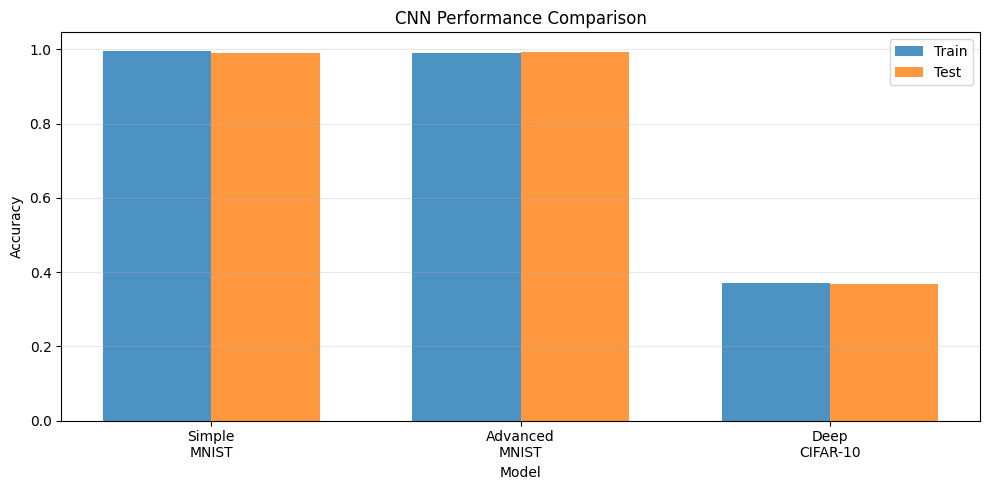

In [15]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Simple CNN (MNIST)', 'Advanced CNN (MNIST)', 'Deep CNN (CIFAR-10)'],
    'Dataset': ['MNIST', 'MNIST', 'CIFAR-10'],
    'Train Accuracy': [train_acc_s, train_acc_a, train_acc_c],
    'Test Accuracy': [test_acc_s, test_acc_a, test_acc_c]
})

print("\n=== CNN Model Comparison ===")
print(comparison_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comparison_df))
width = 0.35

ax.bar(x - width/2, comparison_df['Train Accuracy'], width, label='Train', alpha=0.8)
ax.bar(x + width/2, comparison_df['Test Accuracy'], width, label='Test', alpha=0.8)

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('CNN Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(['Simple\nMNIST', 'Advanced\nMNIST', 'Deep\nCIFAR-10'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### 10. Save Models

In [16]:
# Save models
advanced_cnn.save('cnn_mnist_advanced.keras')
deep_cnn_cifar.save('cnn_cifar10_deep.keras')

print("Models saved successfully!")
print("- cnn_mnist_advanced.keras")
print("- cnn_cifar10_deep.keras")

Models saved successfully!
- cnn_mnist_advanced.keras
- cnn_cifar10_deep.keras
